In [8]:
from src.utils import get_data_env
from src.dataloading import EpiConfig, DataOrchestrator, BaseLineDataLoaderManager, DeepDataLoaderManager
from src.models import PersistenceModel, ClimateologyModel, NodeLSTMModel

In [9]:
# get data
disease_name    = 'influenza'
nuts_level      = 'nuts3'
min_date        = '2011-06-01'
max_date        = '2020-06-01'
split_trainval  = '2018-06-01'
split_valtest   = '2019-06-01'
split_berlin    = False

horizon_size    = 1
horizon_leadtime= 3
sequence_length = 1
lag_num         = 1

config = EpiConfig(
    disease             = disease_name,
    data_env_dir        = get_data_env(),
    date_range          = (min_date, max_date),
    horizon_size        = horizon_size,
    sequence_length     = sequence_length,
    horizon_leadtime    = horizon_leadtime,
    lag_num             = lag_num,
    nuts_level          = nuts_level,
    log_transform       = ['incidence'],
    split_berlin        = split_berlin,
    include_population  = True,
    split_trainval      = split_trainval, 
    split_valtest       = split_valtest,
    target_column       = 'incidence',
    lag_column          = 'incidence',  
    verbose             = 0
    )    

data_orchestrator = (DataOrchestrator(config)
                        .load_raw()
                        .harmonize_raw()
                        .process_data()
                        .build_features()
                        .normalize()
                        .finalize()
                        )

In [10]:
import torch
import pandas as pd
import numpy as np 
import os
from typing import List, Tuple, Optional, Union, Literal
from dataclasses import dataclass

from tqdm import tqdm

from src.graphconstruction.containers import GraphStructure, DynamicGraphStructure

from src.utils.textformatting import error_emoji

class GraphStructureError(Exception):
    pass

class DeepData:
    """
    An alternative to the Pytorch Data class for dataentries of X, y

    Parameters
    ----------
    x: torch.Tensor
        input data of shape [num_nodes, sequence_length, num_features]
    y: torch.Tensor
        target data of shape [num_nodes, horizon_size]
    """
    def __init__(self, 
                 x:             torch.Tensor, 
                 y:             torch.Tensor):
        
        self.x          = x
        self.y          = y

    def to(self, device: torch.device) -> 'DeepData':
        """Move all tensors to the specified device (GPU)"""
        return DeepData(
            x=self.x.to(device),
            y=self.y.to(device),
        )        
    
    def __repr__(self):
        cls = self.__class__.__name__
        info = (
            f"x={tuple(self.x.shape)}, "
            f"y={tuple(self.y.shape)}"
        )
        return f"{cls}({info})"
    
class DeepDataLoader:
    """
    An alternative to the Pytorch DataLoader class
    Basically a list of GraphData entries
    """    
    def __init__(self, data_list: List[DeepData]):
        self.data_list = data_list

    def __iter__(self):
        return iter(self.data_list)
    
    def __len__(self):
        return len(self.data_list)

    def __getitem__(self, idx: int) -> DeepData:
        return self.data_list[idx]
    
    def __repr__(self):
        cls = self.__class__.__name__
        if not self.data_list:
            return f"{cls}(empty)"
        snapshot = self.data_list[0]
        info = (
            f"{len(self.data_list)} datapoints, "
            f"sample: x={tuple(snapshot.x.shape)}, "
            f"y={tuple(snapshot.y.shape)}"
        )
        return f"{cls}({info})"      
    
@dataclass
class DeepDataLoaderCollection:
    """ 
    """
    train:              'DeepDataLoader'
    val:                'DeepDataLoader'   
    test:               'DeepDataLoader'
    main:               'DeepDataLoader'

    def __repr__(self):
        return (f"<DeepDataLoaderCollection(train, val, test, main)>") 

class DeepDataLoaderManager:
    """
    """
    def __init__(self, 
                 dataorchestrator: DataOrchestrator):
        
        self.dataorchestrator       = dataorchestrator
        self.column_registration    = dataorchestrator.column_registration

    def construct_dataloaders(self):
        """
        creates the actual dataloaders
        """
        X,y,t                             = self._construct_Xy(self.dataorchestrator.data_final.data)
        main_dataloader                   = self._construct_main_dataloader(X = X, y = y, t= t)
        self.dataloader_collection        = self._split_dataloader(main_dataloader = main_dataloader)
        return self     
    
    def _construct_Xy(self, 
                      df: pd.DataFrame) -> Tuple[torch.Tensor, torch.Tensor, List[pd.Timestamp]]:
        """
        constructs torch.tensor objects from df, which should be the dataorchestrator's final data object.
        
        Returns:
        -------
        X: torch.Tensor
            Input data of shape [num_timestamps, num_nodes, num_features]
        y: torch.Tensor
            Target data of shape [num_timestamps, num_nodes, horizon_size]    
        t: List[pd.Timestamp]      
            List of timestamps associacted with each datapoint of length [num_timestamps]
        """

        dfc                 = df.copy()
        feature_arrays      = []
        target_arrays       = []
        t                   = dfc['timestamp'].unique().tolist()

        feature_cols = self.column_registration.get_by_type('feature')
        split_cols   = self.column_registration.get_by_type('split')
        target_cols  = self.column_registration.get_by_type('target')          

        time_splits         = dfc[['timestamp'] + split_cols].drop_duplicates().reset_index(drop = True)
        self.time_splits    = time_splits


        # create feature_arrays:
        # a list of np.arrays. Each array is of shape [num_timestamp, num_nodes]
        # which are merged together into a list of an array per feature.
        for feat in feature_cols:
            dtype = dfc[feat].dtype
            # Pivot from long to wide: rows=time, columns=nodes, values=feature
            pivoted = dfc.pivot(index=['timestamp'], columns='node', values=feat).reset_index(drop = True)

            # convert to numeric
            pivoted = pivoted.apply(pd.to_numeric, errors='coerce')

            # Convert to numpy float array, replace NaNs with 0
            arr = pivoted.values
            if str(dtype).startswith('int'):
                arr = arr.astype(np.int32)
            else:
                arr = arr.astype(np.float32)             # force float32 dtype

            feature_arrays.append(arr)

        
        # create target_arrays using the same approach:
        # a list of np.arrays. Each array is of shape [num_timestamp, num_nodes]
        # which are merged together into a list of an array per target column (per prediction horizon).
        for target in target_cols:
            for dfc_col in dfc.columns:
                
                if target in dfc_col and dfc_col not in feature_cols:
                    dtype = dfc[dfc_col].dtype
                    # Pivot from long to wide: rows=time, columns=nodes, values=feature
                    pivoted = dfc.pivot(index=['timestamp'], columns='node', values=dfc_col).reset_index(drop = True)

                    # convert to numeric
                    pivoted = pivoted.apply(pd.to_numeric, errors='coerce')
                    
                    # Convert to numpy float array, replace NaNs with 0
                    arr = pivoted.values
                    if str(dtype).startswith('int'):
                        arr = arr.astype(np.int32)
                    else:
                        arr = arr.astype(np.float32)   
                    target_arrays.append(arr)
        
        # now reshape the lists of arrays into 3d arrays
        X_np = np.stack(feature_arrays, axis=-1) # [num_timestamps, num_nodes, num_features]
        y_np = np.stack(target_arrays,  axis=-1) # [num_timestamps, num_nodes, horizon_size]

        # convert 3d arrays to tensors
        X_tensor = torch.tensor(X_np, dtype=torch.float) 
        y_tensor = torch.tensor(y_np, dtype=torch.float)
        return X_tensor, y_tensor, t
      
    def _construct_main_dataloader(self, 
                                   X: torch.Tensor,
                                   y: torch.Tensor,
                                   t: List[str]) -> DeepDataLoader:
        """

        Parameters:
        ----------
        X: torch.Tensor
            Input data of shape [num_timestamps, num_nodes, num_features]
        y: torch.Tensor
            Target data of shape [num_timestamps, num_nodes, horizon_size]    
        t: List[pd.Timestamp]      
            List of timestamps associacted with each datapoint of length [num_timestamps]
        """

        dataset = []
        num_timesteps, num_nodes, num_features       = X.shape 
        _, _, num_targets                            = y.shape

        # Calculate maximum valid start position
        # Need: start + periods + prediction_horizon - 1 < num_timesteps
        max_start       = num_timesteps - self.dataorchestrator.config.horizon_leadtime - (self.dataorchestrator.config.horizon_size - 1) - (self.dataorchestrator.config.sequence_length - 1)
        self.max_start  = max_start

        if max_start <= 0:
            raise ValueError(
                f"Not enough data for windowing: T={num_timesteps}, "
                f"sequence_length={self.dataorchestrator.config.sequence_length}, "
                f"horizon_leadtime={self.dataorchestrator.config.horizon_leadtime}, "
                f"horizon_size={self.dataorchestrator.config.horizon_size}. "
                f"Need at least {self.dataorchestrator.config.sequence_length + self.dataorchestrator.config.horizon_leadtime + self.dataorchestrator.config.horizon_size} timesteps."
            )

        for t_idx, start in enumerate(range(max_start)):
            # Input window: periods consecutive timesteps
            x_seq = X[start : start + self.dataorchestrator.config.sequence_length]  # shape [periods, nodes, features]
            y_seq = y[start + self.dataorchestrator.config.sequence_length - 1]
            
            data = DeepData(
                x = x_seq.clone().detach().float().permute(1, 2, 0),  # (nodes, features, periods)
                y = y_seq.clone().detach().float(),                   # (nodes, horizon)
            )
            dataset.append(data)       

        return DeepDataLoader(dataset)

    def _split_dataloader(self, 
                          main_dataloader: DeepDataLoader) -> DeepDataLoaderCollection:
        """
        Splits main dataloader into those for train/val/test
        """        

        train_idx = list(self.time_splits[self.time_splits['train']].index)
        val_idx   = list(self.time_splits[self.time_splits['val']].index)
        test_idx  = list(self.time_splits[self.time_splits['test']].index)

        dataloader_train = DeepDataLoader([main_dataloader[tt] for tt in train_idx])
        dataloader_val   = DeepDataLoader([main_dataloader[tt] for tt in val_idx])
        dataloader_test  = DeepDataLoader([main_dataloader[tt] for tt in test_idx if tt < self.max_start])        
        
        return DeepDataLoaderCollection(
            train = dataloader_train,
            val   = dataloader_val,
            test  = dataloader_test,
            main  = main_dataloader
        )

    def __repr__(self) -> str:

        representation = f'<DeepDataLoaderManager(dataloaders at .dataloader_collection)>'          
        return representation

In [11]:
deepdataloader = DeepDataLoaderManager(data_orchestrator).construct_dataloaders()

In [12]:
deepdataloader.dataloader_collection.train[0]

DeepData(x=(400, 4, 1), y=(400, 1))

In [13]:
n_epochs        = 100
lr              = 0.0001
min_delta       = 0.0001
loss            = 'mse'

global_hparams = {
    "lr"                : lr,
    "n_epochs"          : n_epochs,
    "scheduler"         : 'plateau',
    "scheduler_kwargs"  :  {'mode': 'min', 'factor': 0.5, 'patience': 6},
    'min_delta'         : min_delta,
    'loss'              : loss,
    'patience'          : 20,
    }




==                     plus                     ==
model_hparams_set ✓
global_hparams_set ✓
Dataloader Snapshot: DeepData(x=(400, 4, 1), y=(400, 1))
Epoch 001 train loss: 0.8671, val loss: 1.3372 ✓ (new best)
Epoch 002 train loss: 0.6421, val loss: 0.9343 ✓ (new best)
Epoch 003 train loss: 0.5807, val loss: 0.8546 ✓ (new best)
Epoch 004 train loss: 0.5671, val loss: 0.7883 ✓ (new best)
Epoch 005 train loss: 0.5495, val loss: 0.7396 ✓ (new best)
Epoch 006 train loss: 0.5341, val loss: 0.6882 ✓ (new best)
Epoch 007 train loss: 0.5250, val loss: 0.6532 ✓ (new best)
Epoch 008 train loss: 0.5132, val loss: 0.5970 ✓ (new best)
Epoch 009 train loss: 0.5048, val loss: 0.5912 ✓ (new best)
Epoch 010 train loss: 0.4886, val loss: 0.5043 ✓ (new best)
Epoch 011 train loss: 0.4871, val loss: 0.5334 (patience: 1/20)
Epoch 012 train loss: 0.4646, val loss: 0.4561 ✓ (new best)
Epoch 013 train loss: 0.4708, val loss: 0.4845 (patience: 1/20)
Epoch 014 train loss: 0.4556, val loss: 0.4576 (patience: 2/20

/scratch/de-schrijvers/projects/infectious_disease_gnn/src/models/deep/deepmodel.py:231: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


Early stopping: Validation loss hasn't improved for 20 epochs
Restored model from best validation loss: 0.3502
trained ✓


Forecasting test: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 46/46 [00:00<00:00, 456.19it/s]

Test loss: 0.5719
forecasted ✓


<Fig(n_axes = 1, legend, ticks, labels)>

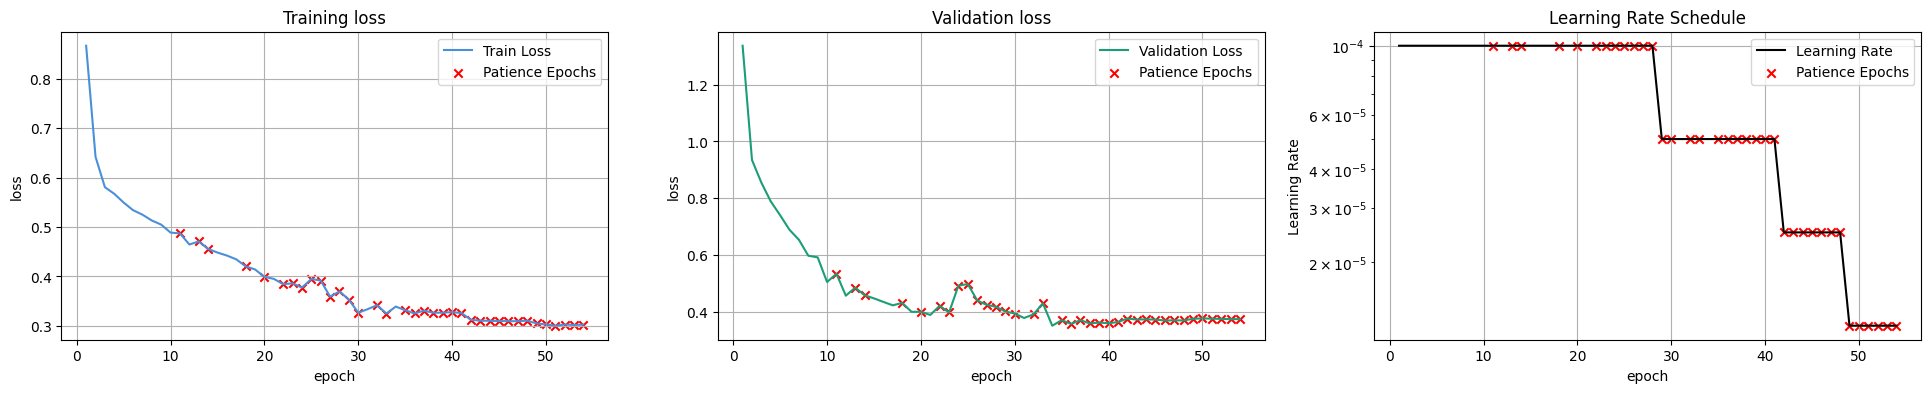

In [14]:
plus = NodeLSTMModel(deepdataloader, name = 'plus', verbose = 10)
plus.set_model_hparams()
plus.set_global_hparams(**global_hparams)
plus.train()
plus.forecast('test')
plus.show_forecasts(26)

In [15]:
dl = BaseLineDataLoaderManager(data_orchestrator)
ps = PersistenceModel(dl)
cm = ClimateologyModel(dl)


ps.forecast('train')
ps.forecast('val')
ps.forecast('test')
raw_f1 = ps.show_forecasts([1], 'test')

cm.forecast('test')
raw_f2 = cm.show_forecasts([1], 'test')

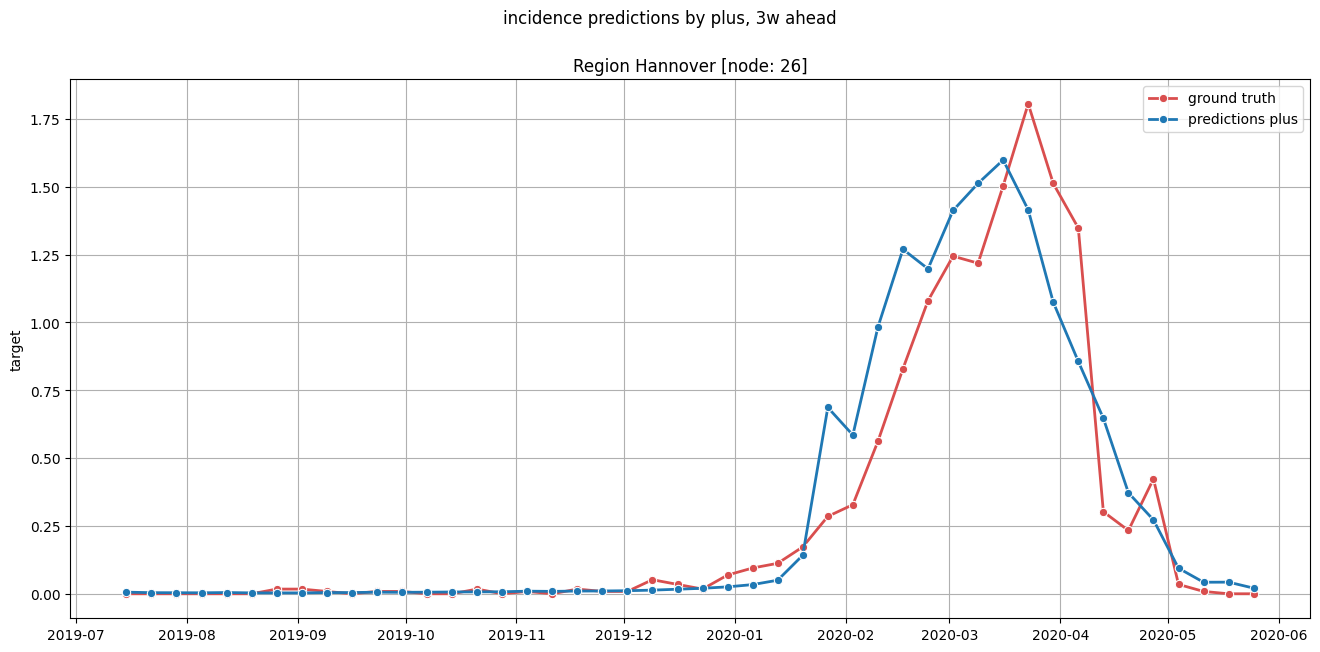

In [18]:
raw_f1 = plus.show_forecasts([26], 'test')
raw_f1.show()

computing metrics: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6/6 [00:02<00:00,  2.05it/s]
/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/evaluationplotter.py:215: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center', fontsize=8)
/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/evaluationplotter.py:215: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center', fontsize=8)
/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/evaluationplotter.py:215: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. af

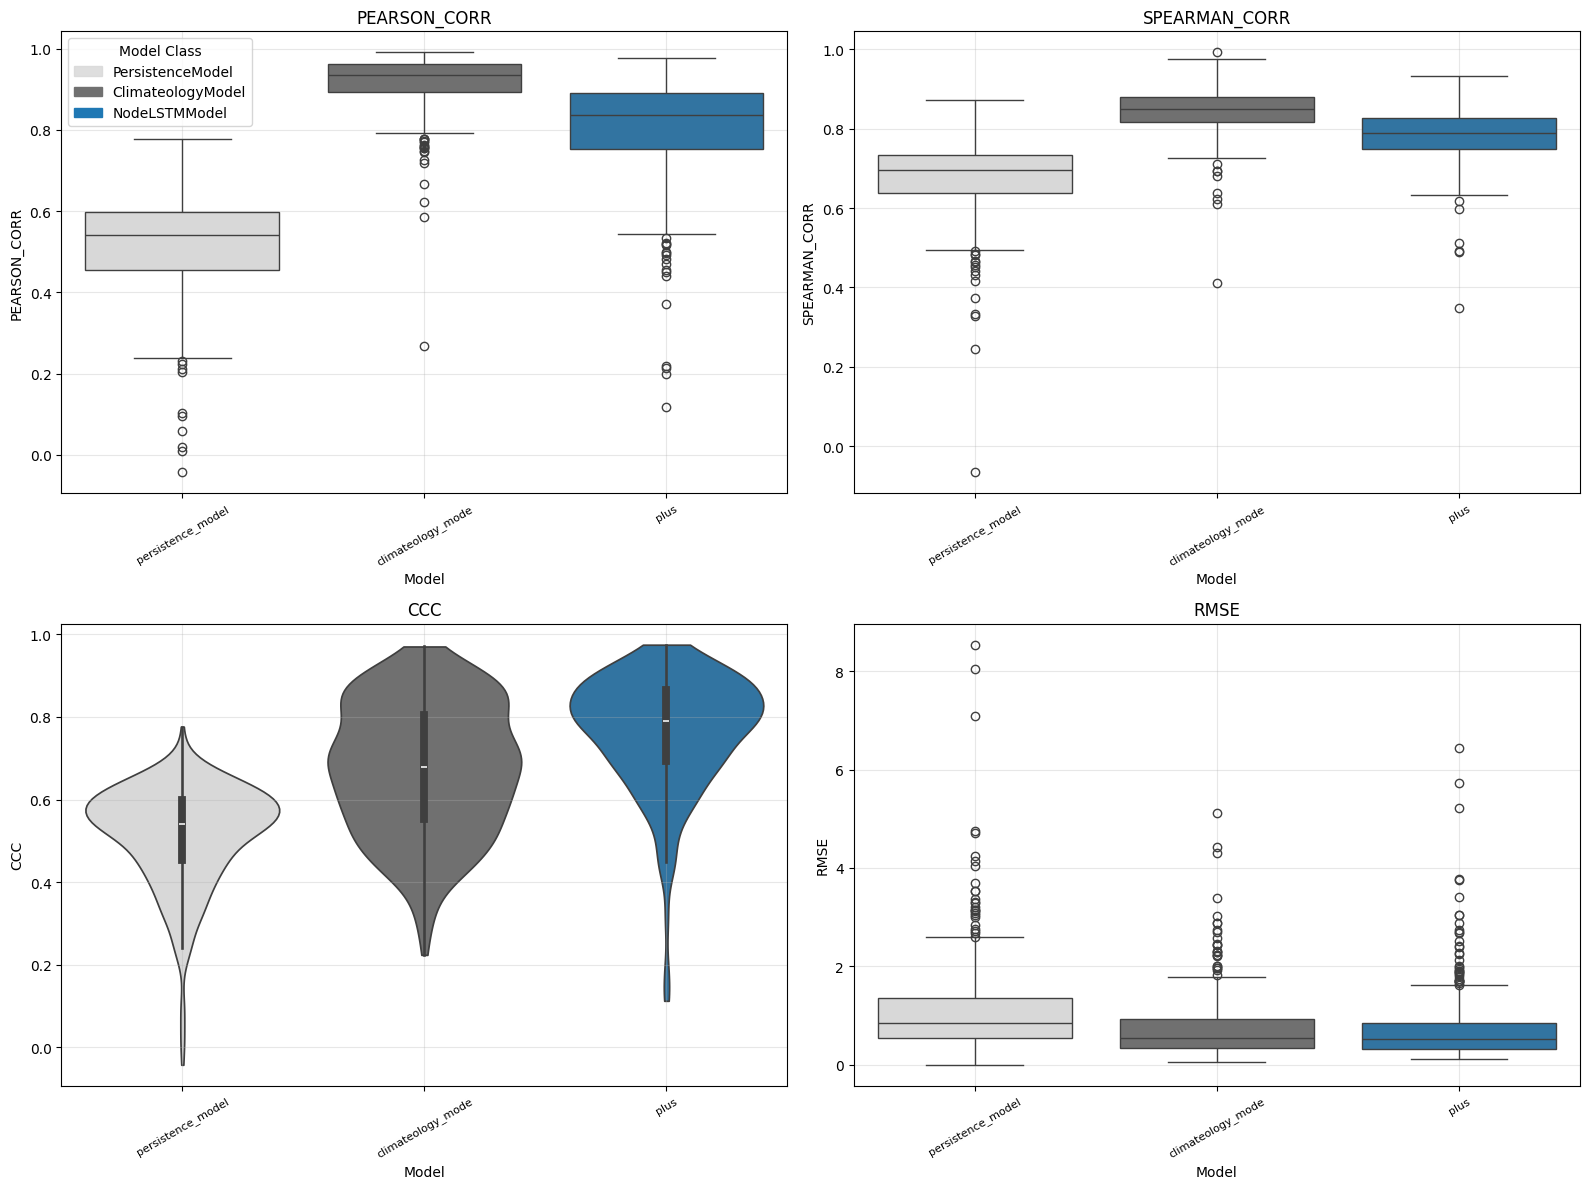

In [19]:
from src.evaluation import Evaluator

e = Evaluator([ps, cm, plus]).add_evaluation()
e.plotter.plot_metric_compilation().show()